To run this, press "*Runtime*" and press "*Run all*" on a **free** Tesla T4 Google Colab instance!
<div class="align-center">
  <a href="https://github.com/unslothai/unsloth"><img src="https://github.com/unslothai/unsloth/raw/main/images/unsloth%20new%20logo.png" width="115"></a>
  <a href="https://discord.gg/unsloth"><img src="https://github.com/unslothai/unsloth/raw/main/images/Discord button.png" width="145"></a>
  <a href="https://docs.unsloth.ai/"><img src="https://github.com/unslothai/unsloth/blob/main/images/documentation%20green%20button.png?raw=true" width="125"></a></a> Join Discord if you need help + ⭐ <i>Star us on <a href="https://github.com/unslothai/unsloth">Github</a> </i> ⭐
</div>

To install Unsloth on your own computer, follow the installation instructions on our Github page [here](https://github.com/unslothai/unsloth?tab=readme-ov-file#-installation-instructions).

**[NEW] As of Novemeber 2024, Unsloth now supports vision finetuning!**

You will learn how to do [data prep](#Data), how to [train](#Train), how to [run the model](#Inference), & [how to save it](#Save)

**This notebook finetunes Qwen2 VL 7B to convert handwritten math formulas into machine readable LaTeX form.**

In [ ]:
%%capture
import os
if "COLAB_" not in "".join(os.environ.keys()):
    !pip install unsloth
else:
    # Do this only in Colab notebooks! Otherwise use pip install unsloth
    !pip install --no-deps bitsandbytes accelerate xformers==0.0.29.post3 peft trl==0.15.2 triton cut_cross_entropy unsloth_zoo
    !pip install sentencepiece protobuf datasets huggingface_hub hf_transfer
    !pip install --no-deps unsloth

* We support Llama 3.2 Vision 11B, 90B; Pixtral; Qwen2VL 2B, 7B, 72B; and any Llava variant like Llava NeXT!
* We support 16bit LoRA via `load_in_4bit=False` or 4bit QLoRA. Both are accelerated and use much less memory!

In [ ]:
from unsloth import FastVisionModel  # FastLanguageModel for LLMs
import torch

# 4bit pre quantized models we support for 4x faster downloading + no OOMs.
fourbit_models = [
    "unsloth/Llama-3.2-11B-Vision-Instruct-bnb-4bit", # Llama 3.2 vision support
    "unsloth/Llama-3.2-11B-Vision-bnb-4bit",
    "unsloth/Llama-3.2-90B-Vision-Instruct-bnb-4bit", # Can fit in a 80GB card!
    "unsloth/Llama-3.2-90B-Vision-bnb-4bit",

    "unsloth/Pixtral-12B-2409-bnb-4bit",              # Pixtral fits in 16GB!
    "unsloth/Pixtral-12B-Base-2409-bnb-4bit",         # Pixtral base model

    "unsloth/Qwen2-VL-2B-Instruct-bnb-4bit",          # Qwen2 VL support
    "unsloth/Qwen2-VL-7B-Instruct-bnb-4bit",
    "unsloth/Qwen2-VL-72B-Instruct-bnb-4bit",

    "unsloth/llava-v1.6-mistral-7b-hf-bnb-4bit",      # Any Llava variant works!
    "unsloth/llava-1.5-7b-hf-bnb-4bit",
] # More models at https://huggingface.co/unsloth

model, tokenizer = FastVisionModel.from_pretrained(
    "unsloth/Qwen2-VL-2B-Instruct",
    load_in_4bit = True, # Use 4bit to reduce memory use. False for 16bit LoRA.
    use_gradient_checkpointing = "unsloth", # True or "unsloth" for long context
)

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
Unsloth: Failed to patch Gemma3ForConditionalGeneration.
🦥 Unsloth Zoo will now patch everything to make training faster!
==((====))==  Unsloth 2025.3.19: Fast Qwen2 patching. Transformers: 4.51.1.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.741 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.6.0+cu124. CUDA: 7.5. CUDA Toolkit: 12.4. Triton: 3.2.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.29.post3. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors:   0%|          | 0.00/2.46G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/238 [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/572 [00:00<?, ?B/s]

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


...

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/11.4M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/392 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/614 [00:00<?, ?B/s]

chat_template.json:   0%|          | 0.00/1.05k [00:00<?, ?B/s]

In [ ]:
from huggingface_hub import login
from google.colab import userdata
import os

token = userdata.get('HF_TOKEN')
login(token=token)

We now add LoRA adapters for parameter efficient finetuning - this allows us to only efficiently train 1% of all parameters.

**[NEW]** We also support finetuning ONLY the vision part of the model, or ONLY the language part. Or you can select both! You can also select to finetune the attention or the MLP layers!

In [ ]:
model = FastVisionModel.get_peft_model(
    model,
    finetune_vision_layers     = True, # False if not finetuning vision layers
    finetune_language_layers   = True, # False if not finetuning language layers
    finetune_attention_modules = True, # False if not finetuning attention layers
    finetune_mlp_modules       = True, # False if not finetuning MLP layers

    r = 16,           # The larger, the higher the accuracy, but might overfit
    lora_alpha = 16,  # Recommended alpha == r at least
    lora_dropout = 0,
    bias = "none",
    random_state = 3407,
    use_rslora = False,  # We support rank stabilized LoRA
    loftq_config = None, # And LoftQ
    # target_modules = "all-linear", # Optional now! Can specify a list if needed
)

Unsloth: Making `model.base_model.model.visual` require gradients


<a name="Data"></a>
### Data Prep
We'll be using a sampled dataset of handwritten maths formulas. The goal is to convert these images into a computer readable form - ie in LaTeX form, so we can render it. This can be very useful for complex formulas.

You can access the dataset [here](https://huggingface.co/datasets/unsloth/LaTeX_OCR). The full dataset is [here](https://huggingface.co/datasets/linxy/LaTeX_OCR).

In [ ]:
import gdown
import os
import zipfile
import os
import json
from transformers.image_utils import load_image


ROOT_FOLDER = "datasetVQA"
os.makedirs(ROOT_FOLDER, exist_ok=True)


def download_annotation(url: str, destination: str):
    file_path = os.path.join(ROOT_FOLDER, destination)
    gdown.download(url, file_path, fuzzy=True)


url_train = "https://drive.google.com/file/d/16x3h386Q_2UfCxT_3vXmPuXLScxid9L6/view?usp=drive_link"
destination_train = "openvqa_train_v2.json"

url_dev = "https://drive.google.com/file/d/1x8nW50igqUT90LUqmL5h66LoCYkkPTZA/view?usp=drive_link"
destination_dev = "openvqa_dev_v2.json"

url_test = "https://drive.google.com/file/d/10azOS9TzgQl8HrztbexlKh08pkyMb4m5/view?usp=drive_link"
destination_test = "openvqa_test_v2.json"

download_annotation(url_train, destination_train)
download_annotation(url_dev, destination_dev)
download_annotation(url_test, destination_test)

Downloading...
From: https://drive.google.com/uc?id=16x3h386Q_2UfCxT_3vXmPuXLScxid9L6
To: /content/datasetVQA/openvqa_train_v2.json
100%|██████████| 5.67M/5.67M [00:00<00:00, 33.0MB/s]
Downloading...
From: https://drive.google.com/uc?id=1x8nW50igqUT90LUqmL5h66LoCYkkPTZA
To: /content/datasetVQA/openvqa_dev_v2.json
100%|██████████| 656k/656k [00:00<00:00, 7.58MB/s]
Downloading...
From: https://drive.google.com/uc?id=10azOS9TzgQl8HrztbexlKh08pkyMb4m5
To: /content/datasetVQA/openvqa_test_v2.json
100%|██████████| 652k/652k [00:00<00:00, 6.31MB/s]


In [ ]:

# https://drive.google.com/file/d/10z-92oXTvX2hIk0ds4yJOOHav5GGiEyc/view?usp=drive_link
file_id = "10z-92oXTvX2hIk0ds4yJOOHav5GGiEyc"


ROOT_FOLDER = "datasetVQA"

destination_zip = os.path.join(ROOT_FOLDER, "images.zip")

gdown.download(f"https://drive.google.com/uc?id={file_id}", destination_zip, quiet=False)

with zipfile.ZipFile(destination_zip, 'r') as zip_ref:
    zip_ref.extractall(ROOT_FOLDER)


Downloading...
From (original): https://drive.google.com/uc?id=10z-92oXTvX2hIk0ds4yJOOHav5GGiEyc
From (redirected): https://drive.google.com/uc?id=10z-92oXTvX2hIk0ds4yJOOHav5GGiEyc&confirm=t&uuid=e59cbd9f-9552-4ed9-beeb-20a94d35fdc5
To: /content/datasetVQA/images.zip
100%|██████████| 1.66G/1.66G [00:31<00:00, 53.0MB/s]


In [ ]:


with open(os.path.join(ROOT_FOLDER, destination_train), 'r') as f:
    train_annotation = json.load(f)

with open(os.path.join(ROOT_FOLDER, destination_dev), 'r') as f:
    dev_annotation = json.load(f)

with open(os.path.join(ROOT_FOLDER, destination_test), 'r') as f:
    test_annotation = json.load(f)

images_train = train_annotation['images']
annotations_train = train_annotation['annotations']
print("Num of images train: ", len(images_train))
print("Num of annotations train: ", len(annotations_train))

images_dev = dev_annotation['images']
annotations_dev = dev_annotation['annotations']
print("Num of images dev: ", len(images_dev))
print("Num of annotations dev: ", len(annotations_dev))

images_test = test_annotation['images']
annotations_test = test_annotation['annotations']
print("Num of images test: ", len(images_test))
print("Num of annotations test: ", len(annotations_test))


Num of images train:  9129
Num of annotations train:  30833
Num of images dev:  1070
Num of annotations dev:  3545
Num of images test:  1000
Num of annotations test:  3536


In [ ]:
import pandas as pd
from PIL import Image
import os

def combine_data(annotation, images):
    data = []
    for i, anno in enumerate(annotation):
        image_id, question, answer = anno['image_id'], anno['question'], anno['answers']
        for image in images:
            if image['id'] == image_id:
                data.append({
                    "image_path": os.path.join(ROOT_FOLDER, "images", image['filename']),
                    "question": question,
                    "answer": answer[0]
                })
    return data


train_data = combine_data(annotations_train, images_train)
dev_data = combine_data(annotations_dev, images_dev)
test_data = combine_data(annotations_test, images_test)

train_df = pd.DataFrame(train_data)
dev_df = pd.DataFrame(dev_data)
test_df = pd.DataFrame(test_data)

train_df.to_csv('train_data.csv', index=False)
dev_df.to_csv('dev_data.csv', index=False)
test_df.to_csv('test_data.csv', index=False)

Let's take an overview look at the dataset. We shall see what the 3rd image is, and what caption it had.

In [ ]:
from torch.utils.data import Dataset
from PIL import Image

system_message = """You are a Vision Language Model specialized in understanding and interpreting diverse real-world images.
Your task is to analyze each image and provide concise, accurate answers to specific questions.
The images may include: urban scenes, rural landscapes, cultural landmarks, street food, traditional festivals, traffic, weather conditions, and daily life .
Focus on identifying objects, activities, locations, and context-specific details.
Respond with short, relevant answers (one word, number, or short phrase). Avoid additional explanation unless explicitly requested."""


def format_data(image, question, answer):
    return [
        {
            "role": "system",
            "content": [
                {
                    "type": "text",
                    "text": system_message
                }
            ],
        },
        {
            "role": "user",
            "content": [
                {
                    "type": "image",
                    "image": image,
                },
                {
                    "type": "text",
                    "text": question,
                }
            ],
        },
        {
            "role": "assistant",
            "content": [
                {
                    "type": "text",
                    "text": answer
                }
            ],
        },
    ]


class VQADataset(Dataset):
    def __init__(self, data_list):
        self.data_list = data_list

    def __len__(self):
        return len(self.data_list)

    def __getitem__(self, idx):
        example = self.data_list[idx]
        image = Image.open(example["image_path"]).convert("RGB")

        question = example["question"]
        answer = example['answer']

        return format_data(image, question, answer)

train_dataset = VQADataset(train_data)
eval_dataset = VQADataset(dev_data)
test_dataset = VQADataset(test_data)

In [ ]:
train_dataset[200]

[{'role': 'system',
  'content': [{'type': 'text',
    'text': 'You are a Vision Language Model specialized in understanding and interpreting diverse real-world images.\nYour task is to analyze each image and provide concise, accurate answers to specific questions.\nThe images may include: urban scenes, rural landscapes, cultural landmarks, street food, traditional festivals, traffic, weather conditions, and daily life .\nFocus on identifying objects, activities, locations, and context-specific details.\nRespond with short, relevant answers (one word, number, or short phrase). Avoid additional explanation unless explicitly requested.'}]},
 {'role': 'user',
  'content': [{'type': 'image',
    'image': <PIL.Image.Image image mode=RGB size=960x956>},
   {'type': 'text', 'text': 'cô gái cầm túi mang trang phục gì ?'}]},
 {'role': 'assistant',
  'content': [{'type': 'text',
    'text': 'cô gái cầm túi mang đầm màu kem'}]}]

<a name="Train"></a>
### Train the model
Now let's use Huggingface TRL's `SFTTrainer`! More docs here: [TRL SFT docs](https://huggingface.co/docs/trl/sft_trainer). We do 60 steps to speed things up, but you can set `num_train_epochs=1` for a full run, and turn off `max_steps=None`. We also support TRL's `DPOTrainer`!

We use our new `UnslothVisionDataCollator` which will help in our vision finetuning setup.

In [ ]:
from unsloth import is_bf16_supported
from unsloth.trainer import UnslothVisionDataCollator
from trl import SFTTrainer, SFTConfig
import wandb

In [ ]:
args = SFTConfig(
    per_device_train_batch_size = 2,
    gradient_accumulation_steps = 4,
    warmup_steps = 1,
    max_steps = 50,
    # num_train_epochs = 1, # Set this instead of max_steps for full training runs
    learning_rate = 2e-4,
    fp16 = not is_bf16_supported(),
    bf16 = is_bf16_supported(),
    logging_steps = 1,
    optim = "adamw_8bit",
    weight_decay = 0.01,
    lr_scheduler_type = "linear",
    seed = 3407,
    eval_strategy="steps",
    eval_steps=0.5, # for eval every 10% of steps.
    output_dir = "outputs",
    report_to = "wandb",     # For Weights and Biases

    # You MUST put the below items for vision finetuning:
    remove_unused_columns = False,
    dataset_text_field = "",
    dataset_kwargs = {"skip_prepare_dataset": True},
    dataset_num_proc = 4,
    max_seq_length = 2048,
)

In [ ]:
PROJECT = "vqa-project"
MODEL_FINETUNED = "Qwen2-VL-2B-VQA-Vietnamese-v2"

os.environ['WANDB_API_KEY'] = userdata.get('WANDB')
wandb.login()

wandb.init(
    project=MODEL_FINETUNED,  # change this
    name=MODEL_FINETUNED,  # change this
    config=args,
)

wandb: WARNING Calling wandb.login() after wandb.init() has no effect.


In [ ]:
FastVisionModel.for_training(model) # Enable for training!

trainer = SFTTrainer(
    model = model,
    tokenizer = tokenizer,
    data_collator = UnslothVisionDataCollator(model, tokenizer), # Must use!
    train_dataset = train_dataset,
    eval_dataset=eval_dataset,
    args = args
)

Unsloth: Model does not have a default image size - using 512


In [ ]:
#@title Show current memory stats
gpu_stats = torch.cuda.get_device_properties(0)
start_gpu_memory = round(torch.cuda.max_memory_reserved() / 1024 / 1024 / 1024, 3)
max_memory = round(gpu_stats.total_memory / 1024 / 1024 / 1024, 3)
print(f"GPU = {gpu_stats.name}. Max memory = {max_memory} GB.")
print(f"{start_gpu_memory} GB of memory reserved.")

GPU = Tesla T4. Max memory = 14.741 GB.
3.131 GB of memory reserved.


In [ ]:
trainer_stats = trainer.train()

==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 30,833 | Num Epochs = 1 | Total steps = 50
O^O/ \_/ \    Batch size per device = 2 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (2 x 4 x 1) = 8
 "-____-"     Trainable parameters = 28,950,528/2,000,000,000 (1.45% trained)


Step,Training Loss,Validation Loss
25,0.416900,0.334883
50,0.290400,0.285918


In [ ]:
#@title Show final memory and time stats
used_memory = round(torch.cuda.max_memory_reserved() / 1024 / 1024 / 1024, 3)
used_memory_for_lora = round(used_memory - start_gpu_memory, 3)
used_percentage = round(used_memory         /max_memory*100, 3)
lora_percentage = round(used_memory_for_lora/max_memory*100, 3)
print(f"{trainer_stats.metrics['train_runtime']} seconds used for training.")
print(f"{round(trainer_stats.metrics['train_runtime']/60, 2)} minutes used for training.")
print(f"Peak reserved memory = {used_memory} GB.")
print(f"Peak reserved memory for training = {used_memory_for_lora} GB.")
print(f"Peak reserved memory % of max memory = {used_percentage} %.")
print(f"Peak reserved memory for training % of max memory = {lora_percentage} %.")

3161.2753 seconds used for training.
52.69 minutes used for training.
Peak reserved memory = 3.447 GB.
Peak reserved memory for training = 0.316 GB.
Peak reserved memory % of max memory = 23.384 %.
Peak reserved memory for training % of max memory = 2.144 %.


In [ ]:
trainer_stats

TrainOutput(global_step=50, training_loss=0.5892859417200088, metrics={'train_runtime': 3161.2753, 'train_samples_per_second': 0.127, 'train_steps_per_second': 0.016, 'total_flos': 1988173129555968.0, 'train_loss': 0.5892859417200088})

<a name="Inference"></a>
### Inference
Let's run the model! You can change the instruction and input - leave the output blank!

We use `min_p = 0.1` and `temperature = 1.5`. Read this [Tweet](https://x.com/menhguin/status/1826132708508213629) for more information on why.

Question:  đại lý cà phê này tên gì ?
Answer:  đại lý xưởng cà phê rang xay hội an ii


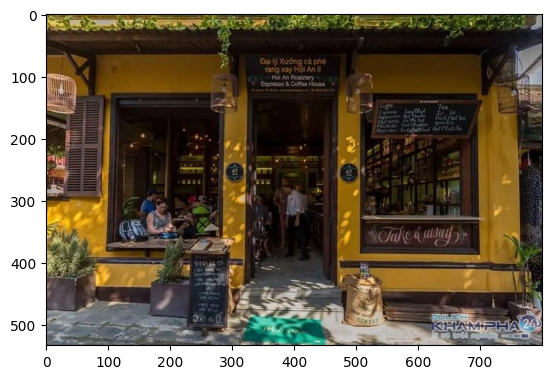

In [ ]:
from PIL import Image
import matplotlib.pyplot as plt

id = 20
image = test_dataset[id][1]['content'][0]['image']
plt.imshow(image)
question = test_dataset[id][1]['content'][1]['text']
answer = test_dataset[id][2]['content'][0]['text']
print("Question: ", question)
print("Answer: ", answer)

In [ ]:
FastVisionModel.for_inference(model) # Enable for inference!

from PIL import Image
import requests
from io import BytesIO
# https://archive.smashing.media/assets/344dbf88-fdf9-42bb-adb4-46f01eedd629/68dd54ca-60cf-4ef7-898b-26d7cbe48ec7/10-dithering-opt.jpg
url = "https://cdnv2.tgdd.vn/mwg-static/common/News/1570960/4-1280x720.jpg"
response = requests.get(url)
image = Image.open(BytesIO(response.content))
question = "Hình ảnh có chữ gì ?"

messages = [
    {"role": "user", "content": [
        {"type": "image"},
        {"type": "text", "text": question}
    ]}
]
input_text = tokenizer.apply_chat_template(messages, add_generation_prompt = True)
inputs = tokenizer(
    image,
    input_text,
    add_special_tokens = False,
    return_tensors = "pt",
).to("cuda")

from transformers import TextStreamer
text_streamer = TextStreamer(tokenizer, skip_prompt = True)
_ = model.generate(**inputs, streamer = text_streamer, max_new_tokens = 128,
                   use_cache = True, temperature = 1.5, min_p = 0.1)

Hình ảnh có chữ là "Claude AI".<|im_end|>


<a name="Save"></a>
### Saving, loading finetuned models
To save the final model as LoRA adapters, either use Huggingface's `push_to_hub` for an online save or `save_pretrained` for a local save.

**[NOTE]** This ONLY saves the LoRA adapters, and not the full model. To save to 16bit or GGUF, scroll down!

In [ ]:
from google.colab import userdata
token = userdata.get('HF_TOKEN')

HF_USER = "DucPTIT"
model.save_pretrained(MODEL_FINETUNED) # Local saving
tokenizer.save_pretrained(MODEL_FINETUNED)


# model.push_to_hub(f"{HF_USER}/{MODEL_FINETUNED}", token = token )# Online saving
# tokenizer.push_to_hub(f"{HF_USER}/{MODEL_FINETUNED}", token = token) # Online saving

[]

Now if you want to load the LoRA adapters we just saved for inference, set `False` to `True`:

In [ ]:
if True:
    from unsloth import FastVisionModel
    model, tokenizer = FastVisionModel.from_pretrained(
        model_name = "./Qwen2-VL-2B-VQA-Vietnamese-v2", # YOUR MODEL YOU USED FOR TRAINING
        load_in_4bit = True, # Set to False for 16bit LoRA
    )
    FastVisionModel.for_inference(model) # Enable for inference!


messages = [
    {"role": "user", "content": [
        {"type": "image"},
        {"type": "text", "text": question}
    ]}
]
input_text = tokenizer.apply_chat_template(messages, add_generation_prompt = True)
inputs = tokenizer(
    image,
    input_text,
    add_special_tokens = False,
    return_tensors = "pt",
).to("cuda")

from transformers import TextStreamer
text_streamer = TextStreamer(tokenizer, skip_prompt = True)
_ = model.generate(**inputs, streamer = text_streamer, max_new_tokens = 128,
                   use_cache = True, temperature = 1.5, min_p = 0.1)

==((====))==  Unsloth 2025.3.19: Fast Qwen2 patching. Transformers: 4.51.1.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.741 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.6.0+cu124. CUDA: 7.5. CUDA Toolkit: 12.4. Triton: 3.2.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.29.post3. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!
Hình ảnh có chữ là "Claude AI".<|im_end|>


### Saving to float16 for VLLM

We also support saving to `float16` directly. Select `merged_16bit` for float16. Use `push_to_hub_merged` to upload to your Hugging Face account! You can go to https://huggingface.co/settings/tokens for your personal tokens.

In [ ]:
# Select ONLY 1 to save! (Both not needed!)

# Save locally to 16bit
if False: model.save_pretrained_merged("unsloth_finetune", tokenizer,)

# To export and save to your Hugging Face account
if False: model.push_to_hub_merged("YOUR_USERNAME/unsloth_finetune", tokenizer, token = "PUT_HERE")

And we're done! If you have any questions on Unsloth, we have a [Discord](https://discord.gg/unsloth) channel! If you find any bugs or want to keep updated with the latest LLM stuff, or need help, join projects etc, feel free to join our Discord!

Some other links:
1. Llama 3.2 Conversational notebook. [Free Colab](https://colab.research.google.com/drive/1T5-zKWM_5OD21QHwXHiV9ixTRR7k3iB9?usp=sharing)
2. Saving finetunes to Ollama. [Free notebook](https://colab.research.google.com/drive/1WZDi7APtQ9VsvOrQSSC5DDtxq159j8iZ?usp=sharing)
3. Llama 3.2 Vision finetuning - Radiography use case. [Free Colab](https://colab.research.google.com/drive/1j0N4XTY1zXXy7mPAhOC1_gMYZ2F2EBlk?usp=sharing)
4. Qwen 2 VL Vision finetuning - Maths OCR to LaTeX. [Free Colab](https://colab.research.google.com/drive/1whHb54GNZMrNxIsi2wm2EY_-Pvo2QyKh?usp=sharing)
5. Pixtral 12B Vision finetuning - General QA datasets. [Free Colab](https://colab.research.google.com/drive/1K9ZrdwvZRE96qGkCq_e88FgV3MLnymQq?usp=sharing)
6. More notebooks for DPO, ORPO, Continued pretraining, conversational finetuning and more on our [Github](https://github.com/unslothai/unsloth)!

<div class="align-center">
  <a href="https://github.com/unslothai/unsloth"><img src="https://github.com/unslothai/unsloth/raw/main/images/unsloth%20new%20logo.png" width="115"></a>
  <a href="https://discord.gg/unsloth"><img src="https://github.com/unslothai/unsloth/raw/main/images/Discord.png" width="145"></a>
  <a href="https://docs.unsloth.ai/"><img src="https://github.com/unslothai/unsloth/blob/main/images/documentation%20green%20button.png?raw=true" width="125"></a></a> Join Discord if you need help + ⭐ <i>Star us on <a href="https://github.com/unslothai/unsloth">Github</a> </i> ⭐
</div>